# MAI203 Lab 5: Probabilistic Information Retrieval using Okapi BM25


## Part 1 - Data Loading


In [11]:
from pathlib import Path
import tarfile
import os

DATA_ARCHIVE = Path("time.tar.gz")
DATA_DIR = Path("time_dataset")
DATA_DIR.mkdir(exist_ok=True)

# Extract the archive only if the key files are not already extracted.
if not (DATA_DIR / "TIME.ALL").exists():
    with tarfile.open(DATA_ARCHIVE, "r:*") as tar:
        tar.extractall(DATA_DIR)

print("Extracted files:")
for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Extracted files:
- README
- TIME.ALL
- TIME.QUE
- TIME.REL
- TIME.STP


## Part 2 - Completed BM25 Implementation

This cell contains the full BM25 implementation. The key pieces are:

- `load_text_documents()` parses `TIME.ALL`.
- `load_queries()` parses `TIME.QUE`.
- `load_qrels()` parses `TIME.REL`.
- `BM25Index._tokenize()` normalizes, tokenizes, removes stopwords and lemmatizes.
- `BM25Index._build()` builds the inverted index.
- `BM25Index.score()` applies the BM25 formula.
- `BM25Index.eval()` computes Precision@k, Recall@k, MAP@k, MRR@k and nDCG@k.


In [12]:
"""
This module implements BM25 from scratch for the TIME test collection.
It includes:
- TIME document/query/qrel parsers
- preprocessing with regex tokenization, lowercasing, stopword removal and WordNet lemmatization
- inverted index construction
- BM25 scoring
- TREC-style run file generation
- evaluation with Precision@k, Recall@k, AP@k/MAP@k, RR@k/MRR@k and nDCG@k
"""

from __future__ import annotations

import math
import re
from collections import Counter, defaultdict, OrderedDict
from pathlib import Path
from typing import Dict, Iterable, List, Tuple, Set, Any

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
except Exception:  # pragma: no cover
    nltk = None
    stopwords = None
    WordNetLemmatizer = None


def _ensure_nltk_resources() -> None:
    """Check for NLTK resources without requiring internet downloads.

    The notebook/code can run offline: if WordNet is unavailable, the BM25 class
    falls back to a small suffix-based lemmatizer.
    """
    return


def _has_wordnet() -> bool:
    if nltk is None:
        return False
    try:
        nltk.data.find("corpora/wordnet")
        return True
    except LookupError:
        try:
            nltk.data.find("corpora/wordnet.zip")
            return True
        except LookupError:
            return False


def load_stopwords(filepath: str | Path | None = None) -> Set[str]:
    """Load NLTK English stopwords plus optional TIME collection stopwords."""
    _ensure_nltk_resources()
    words: Set[str] = set()
    if stopwords is not None:
        try:
            words.update(w.lower() for w in stopwords.words("english"))
        except LookupError:
            pass
    if filepath is not None and Path(filepath).exists():
        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            words.update(line.strip().lower() for line in f if line.strip())
    return words


def load_text_documents(filepath: str | Path) -> List[Dict[str, str]]:
    """Parse TIME.ALL into a list of {'id': doc_id, 'text': text} dictionaries.

    Each document starts with a line like '*TEXT 017 ...'. The numeric part is used as
    the document ID, with leading zeros removed to match TIME.REL qrels.
    """
    docs: List[Dict[str, str]] = []
    current_id: str | None = None
    current_lines: List[str] = []

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            marker = re.match(r"^\*TEXT\s+(\d+)", line)
            if marker:
                if current_id is not None:
                    docs.append({"id": current_id, "text": " ".join(current_lines).lower()})
                current_id = str(int(marker.group(1)))
                current_lines = []
            else:
                if current_id is not None:
                    cleaned = line.strip()
                    if cleaned:
                        current_lines.append(cleaned)

    if current_id is not None:
        docs.append({"id": current_id, "text": " ".join(current_lines).lower()})
    return docs


def load_queries(filepath: str | Path) -> "OrderedDict[str, str]":
    """Parse TIME.QUE into an ordered dictionary qid -> query text."""
    queries: "OrderedDict[str, str]" = OrderedDict()
    current_id: str | None = None
    current_lines: List[str] = []

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            marker = re.match(r"^\*FIND\s+(\d+)", line)
            if marker:
                if current_id is not None:
                    queries[current_id] = " ".join(current_lines).strip()
                current_id = str(int(marker.group(1)))
                current_lines = []
            else:
                if current_id is not None:
                    cleaned = line.strip()
                    if cleaned:
                        current_lines.append(cleaned)

    if current_id is not None:
        queries[current_id] = " ".join(current_lines).strip()
    return queries


def load_qrels(filepath: str | Path) -> Dict[str, Set[str]]:
    """Parse TIME.REL into qid -> set(doc_id) relevance judgments."""
    qrels: Dict[str, Set[str]] = {}
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue
            qid = str(int(parts[0]))
            qrels[qid] = {str(int(doc_id)) for doc_id in parts[1:]}
    return qrels


class BM25Index:
    """BM25Index builds a BM25 search index and supports query scoring."""

    def __init__(self, docs: List[Dict[str, str]], k1: float = 1.2, b: float = 0.75,
                 stopword_file: str | Path | None = None):
        self.k1 = float(k1)
        self.b = float(b)
        self.docs = docs
        self.N = len(docs)
        self.doc_text = {str(doc["id"]): doc["text"] for doc in docs}
        self.ordinal_to_doc_id = {str(i + 1): str(doc["id"]) for i, doc in enumerate(docs)}
        self.doc_len: Dict[str, int] = {}
        self.avgdl = 0.0
        self.df: Dict[str, int] = defaultdict(int)
        self.inv: Dict[str, List[Tuple[str, int]]] = defaultdict(list)
        self.stop_words = load_stopwords(stopword_file)
        _ensure_nltk_resources()
        self.lemmatizer = WordNetLemmatizer() if (WordNetLemmatizer is not None and _has_wordnet()) else None
        self._build()

    def _tokenize(self, text: str) -> List[str]:
        """Lowercase, keep words, lemmatize, and remove stopwords."""
        if not isinstance(text, str):
            return []
        text = text.lower()
        tokens = re.findall(r"[a-z]+", text)
        output: List[str] = []
        for token in tokens:
            if token in self.stop_words or len(token) <= 1:
                continue
            if self.lemmatizer is not None:
                try:
                    token = self.lemmatizer.lemmatize(token)
                except LookupError:
                    # Fallback used in offline environments where WordNet data is unavailable.
                    token = self._simple_lemma(token)
            else:
                token = self._simple_lemma(token)
            if token and token not in self.stop_words and len(token) > 1:
                output.append(token)
        return output

    @staticmethod
    def _simple_lemma(token: str) -> str:
        """Small offline fallback lemmatizer for common English suffixes."""
        if len(token) > 4 and token.endswith("ies"):
            return token[:-3] + "y"
        if len(token) > 5 and token.endswith("ing"):
            return token[:-3]
        if len(token) > 4 and token.endswith("ed"):
            return token[:-2]
        if len(token) > 3 and token.endswith("s"):
            return token[:-1]
        return token

    def _build(self) -> None:
        """Build document lengths, average length, df map, and inverted index."""
        total_len = 0
        for doc in self.docs:
            doc_id = str(doc["id"])
            tokens = self._tokenize(doc.get("text", ""))
            self.doc_len[doc_id] = len(tokens)
            total_len += len(tokens)
            term_counts = Counter(tokens)
            for term, tf in term_counts.items():
                self.inv[term].append((doc_id, int(tf)))
                self.df[term] += 1
        self.avgdl = total_len / self.N if self.N else 0.0

    def _idf(self, term: str) -> float:
        """Robertson-Sparck Jones-style smoothed IDF."""
        n_q = self.df.get(term, 0)
        return math.log(((self.N - n_q + 0.5) / (n_q + 0.5)) + 1.0)

    def score(self, query: str, top_k: int = 10) -> List[Tuple[str, float]]:
        """Score all matching documents for a query and return top-k (doc_id, score)."""
        query_terms = self._tokenize(query)
        scores: Dict[str, float] = defaultdict(float)
        for term in query_terms:
            postings = self.inv.get(term, [])
            if not postings:
                continue
            idf = self._idf(term)
            for doc_id, tf in postings:
                dl = self.doc_len.get(doc_id, 0)
                denom = tf + self.k1 * (1.0 - self.b + self.b * dl / self.avgdl) if self.avgdl else tf + self.k1
                scores[doc_id] += idf * ((tf * (self.k1 + 1.0)) / denom)
        ranked = sorted(scores.items(), key=lambda pair: (-pair[1], int(pair[0]) if pair[0].isdigit() else pair[0]))
        return ranked[:top_k]

    def info(self) -> str:
        """Return a short summary of index configuration."""
        return f"BM25Index(k1={self.k1}, b={self.b}, N={self.N}, avgdl={self.avgdl:.2f}, vocab={len(self.inv)})"

    def run_queries(self, query_file: str | Path = "time.QUE", output_file: str | Path = "run.txt",
                    top_k: int = 100, run_tag: str = "BM25") -> None:
        """Run all queries and write a TREC-style run file."""
        queries = load_queries(query_file)
        with open(output_file, "w", encoding="utf-8") as out:
            for qid, qtext in queries.items():
                results = self.score(qtext, top_k=top_k)
                for rank, (doc_id, score) in enumerate(results, start=1):
                    out.write(f"{qid} Q0 {doc_id} {rank} {score:.6f} {run_tag}\n")

    @staticmethod
    def _parse_run(run_file: str | Path, k: int) -> Dict[str, List[str]]:
        run: Dict[str, List[Tuple[int, str]]] = defaultdict(list)
        with open(run_file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                parts = line.split()
                if len(parts) < 6:
                    continue
                qid, _, doc_id, rank, *_ = parts
                rank_int = int(rank)
                if rank_int <= k:
                    run[str(int(qid))].append((rank_int, str(int(doc_id)) if doc_id.isdigit() else doc_id))
        return {qid: [doc_id for _, doc_id in sorted(items)] for qid, items in run.items()}

    @staticmethod
    def _dcg(rels: List[int]) -> float:
        return sum(rel / math.log2(i + 2) for i, rel in enumerate(rels))

    def eval(self, run_file: str | Path = "run.txt", rel_file: str | Path = "time.REL", k: int = 10) -> Dict[str, Any]:
        """Evaluate P@k, R@k, AP@k, RR@k, nDCG@k, MAP@k, and MRR@k."""
        run = self._parse_run(run_file, k)
        qrels = load_qrels(rel_file)
        # TIME.REL uses collection-order IDs in some distributions, while TIME.ALL
        # uses original *TEXT IDs with gaps. If qrel IDs do not match actual document
        # IDs, map collection-order IDs to original *TEXT IDs for evaluation.
        all_doc_ids = set(self.doc_text.keys())
        mapped_qrels = {}
        for qid, rels in qrels.items():
            if rels and not rels.issubset(all_doc_ids):
                mapped_qrels[qid] = {self.ordinal_to_doc_id.get(r, r) for r in rels}
            else:
                mapped_qrels[qid] = rels
        qrels = mapped_qrels
        qids = sorted(qrels.keys(), key=lambda x: int(x))
        per_query: Dict[str, Dict[str, float]] = {}
        for qid in qids:
            relevant = qrels.get(qid, set())
            retrieved = run.get(qid, [])[:k]
            rels = [1 if doc_id in relevant else 0 for doc_id in retrieved]
            # pad to k for fixed-cutoff P@k and nDCG@k
            padded_rels = rels + [0] * max(0, k - len(rels))
            hits = sum(rels)
            precision_at_k = hits / k if k else 0.0
            recall_at_k = hits / len(relevant) if relevant else 0.0
            precisions_at_hits = []
            for i, rel in enumerate(rels, start=1):
                if rel:
                    precisions_at_hits.append(sum(rels[:i]) / i)
            denom = min(len(relevant), k) if relevant else 0
            ap_at_k = sum(precisions_at_hits) / denom if denom else 0.0
            rr_at_k = 0.0
            for i, rel in enumerate(rels, start=1):
                if rel:
                    rr_at_k = 1.0 / i
                    break
            dcg = self._dcg(padded_rels[:k])
            ideal_rels = [1] * min(len(relevant), k) + [0] * max(0, k - min(len(relevant), k))
            idcg = self._dcg(ideal_rels[:k])
            ndcg_at_k = dcg / idcg if idcg else 0.0
            per_query[qid] = {
                f"P@{k}": precision_at_k,
                f"R@{k}": recall_at_k,
                f"AP@{k}": ap_at_k,
                f"RR@{k}": rr_at_k,
                f"nDCG@{k}": ndcg_at_k,
                "hits": hits,
                "num_relevant": len(relevant),
            }
        macro = {
            f"P@{k}": sum(v[f"P@{k}"] for v in per_query.values()) / len(per_query) if per_query else 0.0,
            f"R@{k}": sum(v[f"R@{k}"] for v in per_query.values()) / len(per_query) if per_query else 0.0,
            f"MAP@{k}": sum(v[f"AP@{k}"] for v in per_query.values()) / len(per_query) if per_query else 0.0,
            f"MRR@{k}": sum(v[f"RR@{k}"] for v in per_query.values()) / len(per_query) if per_query else 0.0,
            f"nDCG@{k}": sum(v[f"nDCG@{k}"] for v in per_query.values()) / len(per_query) if per_query else 0.0,
        }
        return {"k": k, "num_queries": len(per_query), "per_query": per_query, "macro": macro}


## Load Documents, Queries, and Relevance Judgments

This step loads the TIME documents, the user information needs/queries and the relevance judgments used for evaluation.

In [13]:
docs = load_text_documents(DATA_DIR / "TIME.ALL")
queries = load_queries(DATA_DIR / "TIME.QUE")
qrels = load_qrels(DATA_DIR / "TIME.REL")

print(f"Number of documents: {len(docs)}")
print(f"Number of queries: {len(queries)}")
print(f"Number of qrel rows: {len(qrels)}")
print("\nFirst document:")
print(docs[0]["id"], docs[0]["text"][:500])
print("\nFirst query:")
print(list(queries.items())[0])

Number of documents: 423
Number of queries: 83
Number of qrel rows: 83

First document:
17 the allies after nassau in december 1960, the u.s . first proposed to help nato develop its own nuclear strike force . but europe made no attempt to devise a plan . last week, as they studied the nassau accord between president kennedy and prime minister macmillan, europeans saw emerging the first outlines of the nuclear nato that the u.s . wants and will support . it all sprang from the anglo-u.s . crisis over cancellation of the bug-ridden skybolt missile, and the u.s . offer to supply britain

First query:
('1', 'KENNEDY ADMINISTRATION PRESSURE ON NGO DINH DIEM TO STOP SUPPRESSING THE BUDDHISTS .')


## Build the Default BM25 Index

BM25 defaults k1=1.2 and b=0.75.

- k1 controls term-frequency saturation.
- b controls document-length normalization.

In [14]:
default_index = BM25Index(docs, k1=1.2, b=0.75, stopword_file=DATA_DIR / "TIME.STP")
print(default_index.info())

# Show a small sample of the inverted index.
sample_terms = list(default_index.inv.keys())[:10]
for term in sample_terms:
    print(term, "->", default_index.inv[term][:3])

BM25Index(k1=1.2, b=0.75, N=423, avgdl=283.72, vocab=18106)
ally -> [('17', 2), ('47', 1), ('58', 2)]
nassau -> [('17', 4), ('40', 1), ('45', 1)]
december -> [('17', 1), ('70', 1), ('86', 1)]
proposed -> [('17', 1), ('71', 1), ('86', 1)]
help -> [('17', 3), ('34', 5), ('50', 2)]
nato -> [('17', 7), ('47', 3), ('63', 1)]
develop -> [('17', 2), ('32', 1), ('63', 1)]
nuclear -> [('17', 10), ('55', 1), ('62', 5)]
strike -> [('17', 2), ('21', 1), ('29', 1)]
force -> [('17', 10), ('21', 5), ('27', 1)]


## Score a Single Query

This demonstrates how BM25 ranks documents for a query.  
Each query term contributes a score only to documents that contain the term.   
The final document score is the sum of all query-term BM25 contributions.  

In [15]:
query_id = "1"
query_text = queries[query_id]
results = default_index.score(query_text, top_k=10)

print("Query", query_id, ":", query_text)
print("\nTop 10 results:")
for rank, (doc_id, score) in enumerate(results, start=1):
    snippet = default_index.doc_text[doc_id][:200].replace("\n", " ")
    print(f"{rank:>2}. doc_id={doc_id:<4} score={score:.4f} | {snippet}...")

Query 1 : KENNEDY ADMINISTRATION PRESSURE ON NGO DINH DIEM TO STOP SUPPRESSING THE BUDDHISTS .

Top 10 results:
 1. doc_id=390  score=21.9685 | south viet nam suicide in many forms a south vietnamese novelist and politician named nguyen tuong tam sent his sons out to buy a bottle of whisky one night last week . for a while he sat drinking wit...
 2. doc_id=464  score=20.5468 | south viet nam report on the war overshadowed by the political and diplomatic turmoil in saigon, the all but forgotten war against the viet cong continues on its ugly, bloody and wearisome course . th...
 3. doc_id=320  score=20.4729 | south viet nam 2-12 the religious crisis a dusk-to-dawn curfew emptied the streets of the ancient vietnamese capital of hue, 400 miles north of saigon . riot police and armored personnel carriers patr...
 4. doc_id=334  score=20.2246 | south viet nam trial by fire the automobile at the head of the procession of saffron-robed buddhist monks in saigon suddenly choked to a stop at an 

## Run All Queries and Evaluate

The notebook writes a TREC-style run file and evaluates the run at several cutoffs.  
The lab asks for MAP@k, nDCG@k, recall@k and precision@k. The implementation also reports MRR@k.

In [16]:
import pandas as pd

run_file = Path("MAI203_Lab5_run_default.txt")
default_index.run_queries(DATA_DIR / "TIME.QUE", run_file, top_k=100, run_tag="BM25_DEFAULT")

metric_rows = []
for k in [3, 5, 10, 20]:
    report = default_index.eval(run_file, DATA_DIR / "TIME.REL", k=k)
    row = {"k": k}
    row.update(report["macro"])
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
metrics_df.to_csv("MAI203_Lab5_default_metrics_by_k.csv", index=False)
metrics_df

,k,P@3,R@3,MAP@3,MRR@3,nDCG@3,P@5,R@5,MAP@5,MRR@5,...,P@10,R@10,MAP@10,MRR@10,nDCG@10,P@20,R@20,MAP@20,MRR@20,nDCG@20
0,3,0.269076,0.17912,0.258367,0.331325,0.289796,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,NaN,NaN,NaN,NaN,NaN,0.240964,0.250688,0.255067,0.340361,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.187952,0.350214,0.264566,0.347103,0.320617,NaN,NaN,NaN,NaN,NaN
3,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.111446,0.390915,0.270696,0.34891,0.332142


## Visualize Performance by Cutoff k

This plot shows how retrieval quality changes as the cutoff expands from top-3 to top-20 documents.  
Precision often decreases as k increases, while recall usually increases because more relevant documents have a chance to appear.

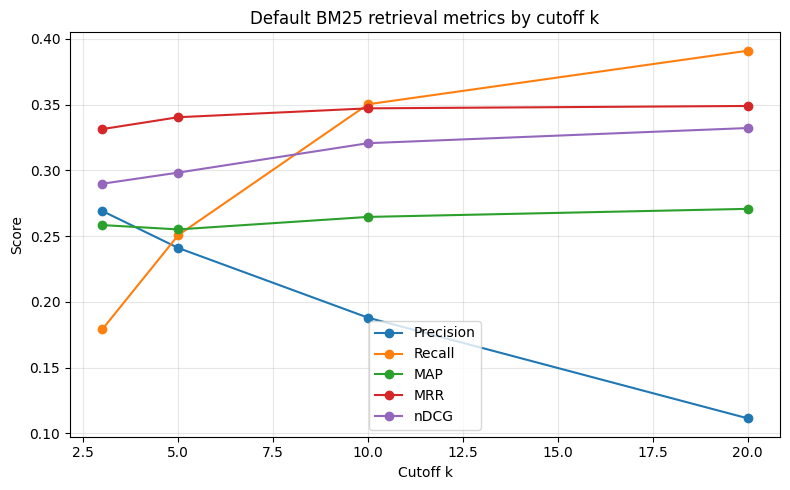

In [17]:
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    "k": [3, 5, 10, 20],
    "Precision": [row[f"P@{row['k']}"] for row in metric_rows],
    "Recall": [row[f"R@{row['k']}"] for row in metric_rows],
    "MAP": [row[f"MAP@{row['k']}"] for row in metric_rows],
    "MRR": [row[f"MRR@{row['k']}"] for row in metric_rows],
    "nDCG": [row[f"nDCG@{row['k']}"] for row in metric_rows],
})

fig, ax = plt.subplots(figsize=(8, 5))
for metric in ["Precision", "Recall", "MAP", "MRR", "nDCG"]:
    ax.plot(plot_df["k"], plot_df[metric], marker="o", label=metric)
ax.set_title("Default BM25 retrieval metrics by cutoff k")
ax.set_xlabel("Cutoff k")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("MAI203_Lab5_default_metrics_by_k.png", dpi=180)
plt.show()

## Parameter Tuning: k1 and b

The lab asks for a plot of performance against k1 and b. The grid below tests:

- k1: 0.8, 1.0, 1.2, 1.5, 2.0
- b: 0.0, 0.25, 0.5, 0.75, 1.0

The comparison metric used here is MAP@10.

In [18]:
tuning_rows = []
for k1 in [0.8, 1.0, 1.2, 1.5, 2.0]:
    for b in [0.0, 0.25, 0.5, 0.75, 1.0]:
        index = BM25Index(docs, k1=k1, b=b, stopword_file=DATA_DIR / "TIME.STP")
        tune_run_file = Path(f"run_k1_{k1}_b_{b}.txt")
        index.run_queries(DATA_DIR / "TIME.QUE", tune_run_file, top_k=100, run_tag=f"BM25_k1{k1}_b{b}")
        macro = index.eval(tune_run_file, DATA_DIR / "TIME.REL", k=10)["macro"]
        tuning_rows.append({"k1": k1, "b": b, **macro})

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv("MAI203_Lab5_parameter_tuning_results.csv", index=False)
tuning_df.sort_values("MAP@10", ascending=False).head(10)

,k1,b,P@10,R@10,MAP@10,MRR@10,nDCG@10
21,2.0,0.25,0.190361,0.359016,0.271000,0.371032,0.330520
23,2.0,0.75,0.187952,0.353829,0.269652,0.357932,0.325312
16,1.5,0.25,0.191566,0.360522,0.268173,0.363186,0.327734
24,2.0,1.00,0.183133,0.342028,0.266247,0.363468,0.321227
11,1.2,0.25,0.190361,0.359427,0.266239,0.360576,0.325911
18,1.5,0.75,0.186747,0.347805,0.265797,0.349900,0.320505
13,1.2,0.75,0.187952,0.350214,0.264566,0.347103,0.320617
22,2.0,0.50,0.187952,0.350488,0.264310,0.359251,0.322333
12,1.2,0.50,0.189157,0.356755,0.263628,0.354920,0.322869
19,1.5,1.00,0.181928,0.342128,0.263171,0.357946,0.318759


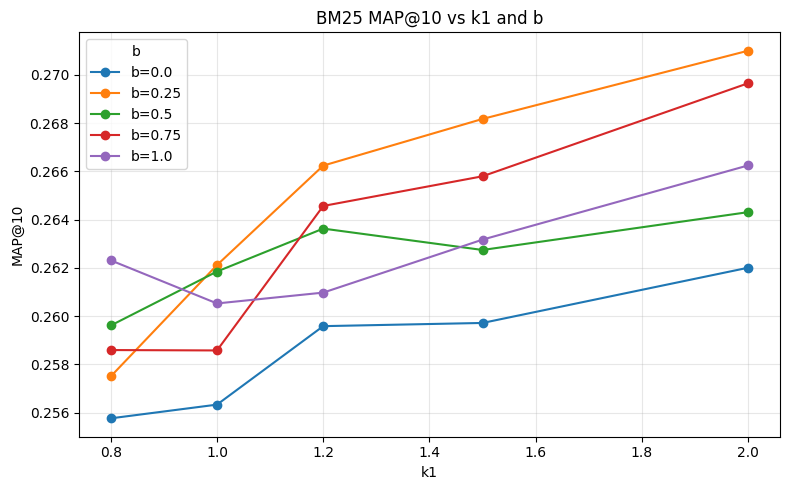

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for b, sub in tuning_df.groupby("b"):
    ax.plot(sub["k1"], sub["MAP@10"], marker="o", label=f"b={b}")
ax.set_title("BM25 MAP@10 vs k1 and b")
ax.set_xlabel("k1")
ax.set_ylabel("MAP@10")
ax.grid(True, alpha=0.3)
ax.legend(title="b")
plt.tight_layout()
plt.savefig("MAI203_Lab5_MAP_vs_k1_b.png", dpi=180)
plt.show()

## Top-3 Retrieved Example with Justification

For Query 1, the table below shows the top-3 documents and the query terms found in each document.  
Documents rank highly when they contain several rare or important query terms with meaningful term frequency and reasonable document length normalization.

In [20]:
top3_rows = []
query_id = "1"
query_terms = default_index._tokenize(queries[query_id])
for rank, (doc_id, score) in enumerate(default_index.score(queries[query_id], top_k=3), start=1):
    doc_tokens = set(default_index._tokenize(default_index.doc_text[doc_id]))
    matched_terms = [term for term in query_terms if term in doc_tokens]
    top3_rows.append({
        "query_id": query_id,
        "rank": rank,
        "doc_id": doc_id,
        "score": round(score, 4),
        "matched_terms": ", ".join(matched_terms),
        "snippet": default_index.doc_text[doc_id][:300].replace("\n", " ")
    })

top3_df = pd.DataFrame(top3_rows)
top3_df.to_csv("MAI203_Lab5_top3_query1.csv", index=False)
top3_df

,query_id,rank,doc_id,score,matched_terms,snippet
0,1,1,390,21.9685,"kennedy, ngo, dinh, diem, buddhist",south viet nam suicide in many forms a south v...
1,1,2,464,20.5468,"kennedy, ngo, dinh, diem, stop, buddhist",south viet nam report on the war overshadowed ...
2,1,3,320,20.4729,"ngo, dinh, diem, buddhist",south viet nam 2-12 the religious crisis a dus...
